# OGLE-I transient peaks observed with Rubin/LSST WFD

This notebook reads the OGLE CV/DN peak bank, puts random peaks on an OGLE-I baseline, makes all six LSST bands with a 12,000 K blackbody (Buckley et. al 2024), and uses **LightCurveLynx** for the Rubin WFD cadence and noise.

## 1. Imports and configuration

In [75]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.modeling import models
from astropy import units as u
from speclite.filters import load_filter
from tqdm.auto import tqdm

from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.models.lightcurve_template_model import LightcurveTemplateModel
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves

SEED = 42
rng = np.random.default_rng(SEED)

PEAK_BANK_PATH = Path('output/DN_peaks_bank.pkl')
OUTPUT_PATH = Path('output/CV_Rubin_WFD_ugrizy_demo.pkl')
OPSIM_LOCAL_PATH = None  # e.g. Path('/path/to/baseline_v5.3.1_10yrs.db')
OPSIM_URL = (
    'https://s3df.slac.stanford.edu/data/rubin/sim-data/'
    'sims_featureScheduler_runs5.3/baseline/baseline_v5.3.1_10yrs.db'
)

FILTERS = list('ugrizy')
SPECLITE_FILTERS = [f'lsst2023-{band}' for band in FILTERS]
FIELD_RA, FIELD_DEC = 270.0, -28.0
MJD_START, NUM_DAYS = 61235.0, 3650.0
MJD_END = MJD_START + NUM_DAYS
N_LIGHTCURVES = 10
MIN_OUTBURSTS = 17
MAX_OUTBURSTS = 90
MIN_PEAK_SEPARATION = 30.0  # days between peak centers
OGLE_I_BASELINE_RANGE = (18.0, 22.5)  # Cousins I, Vega mag
BLACKBODY_TEMPERATURE = 12000.0 * u.K
BAND_COLORS = {'u': '#7b2cbf', 'g': '#2a9d3f', 'r': '#d62728',
               'i': '#f4a261', 'z': '#8c564b', 'y': '#222222'}


## 2. Read and validate transients peak bank

In [76]:
# Reading the saved peak bank.
with open(PEAK_BANK_PATH, 'rb') as file:
    transients_peak_bank = pickle.load(file)

peak_templates_by_source = {}
for source_id in transients_peak_bank:
    source_peaks = transients_peak_bank[source_id]
    source_templates = []
    for peak_index in range(len(source_peaks)):
        peak = source_peaks[peak_index]
        time = np.array(peak['x_new'], dtype=float)
        delta_mag = np.array(peak['y_new'], dtype=float)

        # putting the brightest point at time zero.
        time = time - time[np.argmin(delta_mag)]
        delta_mag = delta_mag - np.max(delta_mag)

        source_templates.append({
            'source_id': source_id,
            'peak_index': peak_index,
            'time': time,
            'delta_mag_I': delta_mag,
        })
    if source_templates:
        peak_templates_by_source[source_id] = source_templates

if len(peak_templates_by_source) == 0:
    raise ValueError('My peak bank is empty.')

n_peak_templates = sum(len(peaks) for peaks in peak_templates_by_source.values())
source_ids = list(peak_templates_by_source)
print(f'Loaded {n_peak_templates} usable peaks from '      f'{len(source_ids)} sources: {PEAK_BANK_PATH}')


Loaded 341 usable peaks from 102 sources: output/DN_peaks_bank.pkl


## 3. Making the LSST bands

Using a 12,000 K blackbody curve, we use the OGLE-I curve as the reference `r` curve, then add the calculated color difference for every LSST band (Buckley et. al. 2024).

In [77]:
# whatever the light curve
lc = pd.DataFrame([[-10, 15], [0, 10], [10, 12], [20, 15]],
                  columns=['Day', 'mag_r'])

# calculating the filter responses
filters = ['lsst2023-u', 'lsst2023-g', 'lsst2023-r',
           'lsst2023-i', 'lsst2023-z', 'lsst2023-y']

# making the blackbody SED from astropy
bb = models.BlackBody(temperature=12000 * u.K)
lmd = np.linspace(1000, 20000, 101) * u.AA
flx = (bb(lmd) * u.sr).to(
    u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(lmd)
)

# calculating the magnitude difference between bands
mags_12K = []
for i in range(len(filters)):
    filt = load_filter(filters[i])
    mag = filt.get_ab_magnitude(flx, lmd)
    mags_12K.append(mag)

mags_12K = np.array(mags_12K)
mags_12K = mags_12K - mags_12K[2]  # difference from lsst-r

# apply to the example light curve
lc['mag_g'] = lc['mag_r'] + mags_12K[1]
lc

# We use the same offsets below for all six bands
LSST_OFFSETS = dict(zip(FILTERS, mags_12K))

def ogle_I_to_lsst(mag_I):
    mag_I = np.asarray(mag_I, dtype=float)
    return {band: mag_I + LSST_OFFSETS[band] for band in FILTERS}


## 4. Load Rubin WFD cadence and noise information

We follow the [original LightCurveLynx OpSim notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/opsim_notebook.html) to load, spatially match, and filter the Rubin observations.

In [78]:
# We load the OpSim 
if OPSIM_LOCAL_PATH is None:
    ops_data = OpSim.from_url(OPSIM_URL)
else:
    ops_data = OpSim.from_db(OPSIM_LOCAL_PATH)

# We find the observations near our chosen sky position.
matches = ops_data.range_search(
    FIELD_RA, FIELD_DEC, radius=ops_data.radius
)
matched_rows = np.zeros(len(ops_data), dtype=bool)
matched_rows[matches] = True
LSST_sim = ops_data.filter_rows(matched_rows)

# We keep observations in our time range and LSST filters.
obs_times = np.asarray(LSST_sim['time'], dtype=float)
obs_filters = np.asarray(LSST_sim['filter']).astype(str)
obs_bands = np.array([name.split('_')[0] for name in obs_filters])
keep = ((obs_times >= MJD_START) & (obs_times <= MJD_END)
        & np.isin(obs_bands, FILTERS))
if not keep.any():
    raise RuntimeError('No visits were found in the selected time range.')
LSST_sim = LSST_sim.filter_rows(keep)

# We use the simple LSST band names expected by the passbands.
selected_data = {column: np.asarray(LSST_sim[column])
                 for column in LSST_sim.columns if column != 'zp'}
selected_data['filter'] = obs_bands[keep]
LSST_sim = OpSim(selected_data)
passband_group = PassbandGroup.from_preset(preset='LSST', filters=FILTERS)

obs_times = np.asarray(LSST_sim['time'], dtype=float)
obs_bands = np.asarray(LSST_sim['filter']).astype(str)
print(f'WFD visits: {len(obs_times):,}; MJD {obs_times.min():.1f}--{obs_times.max():.1f}')
for band in FILTERS:
    print(f'  {band}: {(obs_bands == band).sum():,}')


WFD visits: 2,914; MJD 61235.0--64856.3
  u: 20
  g: 670
  r: 697
  i: 814
  z: 684
  y: 29


## 5. Build OGLE-I baselines and inject peaks randomly

For each light curve we draw a random baseline. We also draw an outburst count from 17 to 90. We give the larger numbers more weight. Then we choose that many random peaks and keep their centers at least 5 days apart.

In [79]:
def abmag_to_njy(mag):
    return 10.0 ** ((31.4 - np.asarray(mag, dtype=float)) / 2.5)

def draw_outburst_count(rng):
    # we give more chance to the larger outburst counts.
    counts = np.arange(MIN_OUTBURSTS, MAX_OUTBURSTS + 1)
    weights = counts.astype(float) ** 2
    weights = weights / weights.sum()
    return int(rng.choice(counts, p=weights))

def build_injected_ogle_I_curve(baseline_I, templates, rng):
    placements = []
    peak_times = []
    # we keep the start, end, and the original peak points.
    grid_pieces = [np.array([MJD_START, MJD_END], dtype=float)]
    for template in templates:
        local_time = template['time']
        low = MJD_START - local_time.min()
        high = MJD_END - local_time.max()

        # we keep drawing a time until it is 5 days away from the other peaks.
        peak_mjd = None
        for attempt in range(10000):
            new_time = rng.uniform(low, high)
            far_enough = all(abs(new_time - old_time) >= MIN_PEAK_SEPARATION
                             for old_time in peak_times)
            if far_enough:
                peak_mjd = new_time
                peak_times.append(peak_mjd)
                break

        if peak_mjd is None:
            raise RuntimeError('I could not find enough peak times 5 days apart.')

        grid_pieces.append(peak_mjd + local_time)
        placements.append({
            'source_id': template['source_id'],
            'peak_index': template['peak_index'],
            'peak_mjd': float(peak_mjd),
            'duration_days': float(local_time.max() - local_time.min()),
            'template': template,
        })

    time = np.unique(np.concatenate(grid_pieces))
    baseline_flux_I = float(abmag_to_njy(baseline_I))
    excess_flux_I = np.zeros_like(time)
    for placement in placements:
        template = placement['template']
        delta_mag = np.interp(
            time - placement['peak_mjd'], template['time'],
            template['delta_mag_I'], left=0.0, right=0.0,
        )
        excess_flux_I += baseline_flux_I * (10.0 ** (-0.4 * delta_mag) - 1.0)

    total_flux_I = baseline_flux_I + excess_flux_I
    I_mag = 31.4 - 2.5 * np.log10(total_flux_I)
    clean_metadata = [{key: value for key, value in item.items() if key != 'template'}
                      for item in placements]
    return time, I_mag, clean_metadata

def make_lightcurvelynx_template(time_mjd, I_mag):
    lsst_mags = ogle_I_to_lsst(I_mag)
    band_curves = {
        band: np.column_stack((time_mjd, abmag_to_njy(lsst_mags[band])))
        for band in FILTERS
    }
    baseline_mags = ogle_I_to_lsst(np.array([I_mag[0]]))
    baseline_fluxes = {band: float(abmag_to_njy(baseline_mags[band][0]))
                       for band in FILTERS}
    source = LightcurveTemplateModel(
        band_curves, passband_group, lc_data_t0=MJD_START, t0=MJD_START,
        baseline=baseline_fluxes,
        ra=NumpyRandomFunc('uniform', low=FIELD_RA, high=FIELD_RA),
        dec=NumpyRandomFunc('uniform', low=FIELD_DEC, high=FIELD_DEC),
        node_label='cv_dn_template',
    )
    return source, {band: float(values[0]) for band, values in baseline_mags.items()}


## 6. Observe the templates with LightCurveLynx

Now we give the six-band template to LightCurveLynx. It samples the template at the WFD times and adds the LSST noise.

In [80]:
def simulate_population(n_lightcurves=N_LIGHTCURVES, rng=rng):
    output = {}
    for index in tqdm(range(n_lightcurves), desc='Rubin WFD CV/DN simulations'):
        baseline_I = rng.uniform(*OGLE_I_BASELINE_RANGE)
        n_peaks = draw_outburst_count(rng)

        # We choose one OGLE source for each simulated LSST light curve.
        source_id = rng.choice(source_ids)
        source_templates = peak_templates_by_source[source_id]
        # We draw all outbursts from that source, with replacement.
        chosen = [source_templates[i]
                  for i in rng.integers(0, len(source_templates), size=n_peaks)]
        template_time, template_I, injected = build_injected_ogle_I_curve(
            baseline_I, chosen, rng
        )
        source, baseline_lsst = make_lightcurvelynx_template(template_time, template_I)
        result = simulate_lightcurves(
            source, 1, LSST_sim, passband_group, num_jobs=1, batch_size=1,
            rng=rng, progress_bar=False,
        )
        lightcurve = result.iloc[0]['lightcurve'].copy()
        lightcurve['mag_ab'] = np.where(
            lightcurve['flux'] > 0,
            31.4 - 2.5 * np.log10(lightcurve['flux']), np.nan,
        )
        lightcurve['magerr'] = np.where(
            lightcurve['flux'] > 0,
            (2.5 / np.log(10.0)) * lightcurve['fluxerr'] / lightcurve['flux'],
            np.nan,
        )
        output[f'cv_rubin_wfd_{index:04d}'] = {
            'lightcurve': lightcurve,
            'baseline_OGLE_I_mag': float(baseline_I),
            'baseline_LSST_ab': baseline_lsst,
            'OGLE_source_id': source_id,
            'outburst_count': n_peaks,
            'minimum_peak_separation_days': MIN_PEAK_SEPARATION,
            'injected_peaks': injected,
            'template_time_mjd': template_time,
            'template_OGLE_I_mag': template_I,
        }
        print(f'{index + 1}: source = {source_id}, '              f'baseline I = {baseline_I:.2f}, outbursts = {n_peaks}')
    return output

simulated_lightcurves = simulate_population()
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_PATH, 'wb') as handle:
    pickle.dump(simulated_lightcurves, handle)
print(f'Saved {len(simulated_lightcurves)} light curves to {OUTPUT_PATH}')


Rubin WFD CV/DN simulations:   0%|          | 0/10 [00:00<?, ?it/s]

1: source = OGLE-BLG-DN-0331, baseline I = 21.48, outbursts = 69
2: source = OGLE-BLG-DN-0635, baseline I = 19.79, outbursts = 61
3: source = OGLE-BLG-DN-0327, baseline I = 20.04, outbursts = 85
4: source = OGLE-BLG-DN-0293, baseline I = 21.68, outbursts = 82
5: source = OGLE-BLG-DN-0002, baseline I = 18.23, outbursts = 90
6: source = OGLE-BLG-DN-0658, baseline I = 20.18, outbursts = 88
7: source = OGLE-BLG-DN-0615, baseline I = 20.63, outbursts = 23
8: source = OGLE-BLG-DN-0461, baseline I = 20.73, outbursts = 82
9: source = OGLE-BLG-DN-0181, baseline I = 18.25, outbursts = 65
10: source = OGLE-BLG-DN-0582, baseline I = 19.57, outbursts = 81
Saved 10 light curves to output/CV_Rubin_WFD_ugrizy_demo.pkl


## 7. Inspect one six-band WFD realization

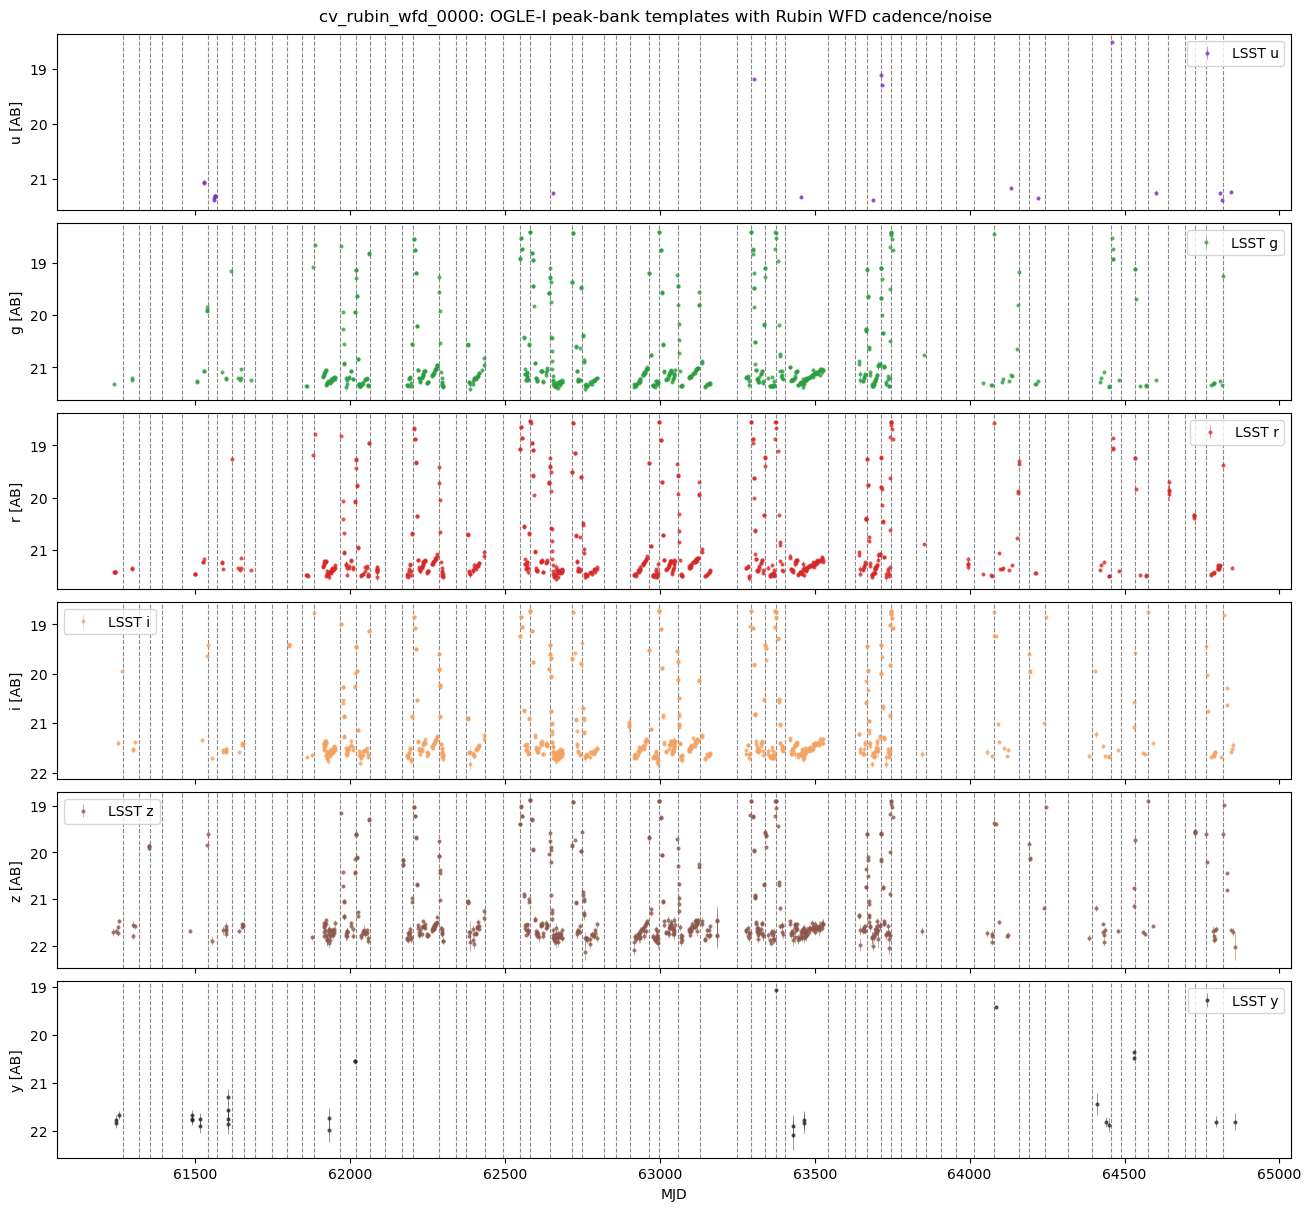

OGLE-I baseline: 21.482802218501835
LSST baselines [AB]: {'u': 21.350383569131314, 'g': 21.344443820287186, 'r': 21.482802218501835, 'i': 21.66794210112494, 'z': 21.83184645360745, 'y': 21.98440332430881}


,source_id,peak_index,peak_mjd,duration_days
0,OGLE-BLG-DN-0331,1,62965.227806,24.98874
1,OGLE-BLG-DN-0331,0,62063.334715,51.20707
...,...,...,...,...
67,OGLE-BLG-DN-0331,0,63906.185362,51.20707
68,OGLE-BLG-DN-0331,0,61692.099267,51.20707


In [81]:
lc_id, record = next(iter(simulated_lightcurves.items()))
lc = record['lightcurve']

fig, axes = plt.subplots(6, 1, figsize=(13, 12), sharex=True, constrained_layout=True)
for ax, band in zip(axes, FILTERS):
    mask = np.asarray(lc['filter']).astype(str) == band
    ax.errorbar(np.asarray(lc['mjd'])[mask], np.asarray(lc['mag_ab'])[mask],
                yerr=np.asarray(lc['magerr'])[mask], fmt='.', ms=4, lw=0.5,
                alpha=0.65, color=BAND_COLORS[band], label=f'LSST {band}')
    for peak in record['injected_peaks']:
        ax.axvline(peak['peak_mjd'], color='0.35', ls='--', lw=0.8, alpha=0.7)
    ax.invert_yaxis()
    ax.set_ylabel(f'{band} [AB]')
    ax.legend(loc='best')
axes[-1].set_xlabel('MJD')
fig.suptitle(f'{lc_id}: OGLE-I peak-bank templates with Rubin WFD cadence/noise')
plt.show()

print('OGLE-I baseline:', record['baseline_OGLE_I_mag'])
print('LSST baselines [AB]:', record['baseline_LSST_ab'])
pd.DataFrame(record['injected_peaks'])


## 8. Zoom in on one peak

Here we choose the longest peak in this light curve. The lines show my full template and the points show the WFD observations with noise.

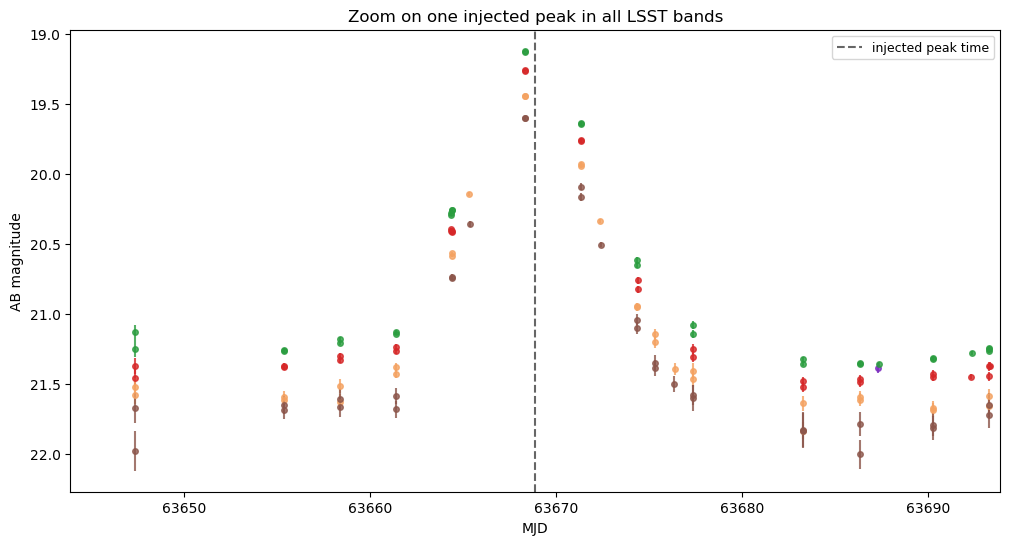

In [82]:
peak = record['injected_peaks'][2] #max(record['injected_peaks'], key=lambda x: x['duration_days'])
peak_time = peak['peak_mjd']
half_window = max(10.0, peak['duration_days'])

template_time = record['template_time_mjd']
template_I = record['template_OGLE_I_mag']
template_bands = ogle_I_to_lsst(template_I)

fig, ax = plt.subplots(figsize=(12, 6))

for band in FILTERS:
    # First we plot the light curve before adding noise.
    # in_template = ((template_time > peak_time - half_window) &
    #                (template_time < peak_time + half_window))
    # ax.plot(template_time[in_template], template_bands[band][in_template],
    #         color=BAND_COLORS[band], lw=2, label=f'{band} template')

    # Then we add the LSST observations in the same band.
    in_data = ((np.asarray(lc['filter']).astype(str) == band) &
               (np.asarray(lc['mjd']) > peak_time - half_window) &
               (np.asarray(lc['mjd']) < peak_time + half_window))
    ax.errorbar(np.asarray(lc['mjd'])[in_data], np.asarray(lc['mag_ab'])[in_data],
                yerr=np.asarray(lc['magerr'])[in_data], fmt='o', ms=4,
                color=BAND_COLORS[band], alpha=0.8)

ax.axvline(peak_time, color='0.4', ls='--', label='injected peak time')
ax.invert_yaxis()
ax.set_xlim(peak_time - half_window, peak_time + half_window)
ax.set_xlabel('MJD')
ax.set_ylabel('AB magnitude')
ax.set_title('Zoom on one injected peak in all LSST bands')
ax.legend(ncol=2, fontsize=9)
plt.show()
